# **Coin Detection, Classification, and Counting**

## Image Processing and Computer Vision - Assignment Module \#1


Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it

## Task
You are given a dataset of photographs containing coins.

Your goal is to build a pipeline that, given an image, detects all coins present, identifies their denomination, and computes the total monetary value shown in the image.

<font color="red"><b>Each step of this assignment must be solved using traditional computer vision techniques.</b></font>

### Example of expected output
```
.
.
.
image_85.jpg - 5 coin(s) found:
  Coin 1 {value: 1.000}
  Coin 2 {value: 0.200}
  Coin 3 {value: 0.100}
  Coin 4 {value: 2.000}
  Coin 5 {value: 0.005}
  Partial Amount {value: 3.350}
image_86.jpg – 3 coin(s) found:
.
.
.

```
<figure>
<a href="https://ibb.co/hxFwbjqg"><img src="https://i.ibb.co/CpKDgZrw/image-85-example.png" alt="image-85-example" border="0"></a>
</figure>

Furthermore, you should provide also the final total amount over all images:
```
.
.
.
Total Amount: TBD €
```

## Data
Two folders of images are provided:
* `reference_set`: eight images, one per coin denomination, each containing a single coin. These images come with a label (their file name is their denomination value) and serve as your reference data. Use them to build and calibrate your classifier;
* `target_set`: a collection of images each containing one or more coins, with no labels. Your pipeline must process each image and output the total monetary value of the coins present.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp -r /content/drive/MyDrive/AssignmentsIPCV/coin_dataset.zip ./
# !unzip coin_dataset.zip

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import os
import time

In [3]:
# CONFIGURATION

TARGET_DIR = "coin_dataset/target_set"
REFERENCE_DIR = "coin_dataset/reference_set"

# Gaussian parameters 
SIGMA = 1.5
K_SIZE = int(np.ceil(3 * SIGMA) * 2 + 1)

print("Gaussian kernel size:", K_SIZE)

# VALUE MAP
COIN_VALUES = {
    "1_cent": 0.01,
    "2_cent": 0.02,
    "5_cent": 0.05,

    "10_cent": 0.10,
    "20_cent": 0.20,
    "50_cent": 0.50,

    "1_euro": 1.00,
    "2_euro": 2.00
}


Gaussian kernel size: 11


In [4]:
# IMAGE LOADING
def load_image(path):
    """
    Load image and fix channel order.

    Dataset images appear stored in RGB order
    while OpenCV loads BGR.

    Manual reversal restores correct colors.
    """
    
    img = cv2.imread(str(path))
    # Show img before changing with plt
    plt.imshow(img)
    plt.title("Before")
    plt.show()

    if img is None:
        raise ValueError(f"Cannot load {path}")

    img = img[:, :, ::-1]
    plt.imshow(img)
    plt.title("After")
    plt.show()

    return img

In [5]:

# ============================================================
# GAUSSIAN FILTERING
# ============================================================

def apply_gaussian(img):

    blurred = cv2.GaussianBlur(
        img,
        (K_SIZE, K_SIZE),
        SIGMA
    )

    return blurred


# ============================================================
# HOUGH DETECTION
# ============================================================

def detect_coins(img):

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    gray = apply_gaussian(gray)

    circles = cv2.HoughCircles(
        gray,
        cv2.HOUGH_GRADIENT,

        dp=1.2,

        minDist=40,

        param1=100,
        param2=28,

        minRadius=45,
        maxRadius=100
    )

    if circles is None:
        return []

    circles = np.round(
        circles[0]
    ).astype(np.int32)

    return circles


# ============================================================
# CIRCULAR MASK EXTRACTION
# ============================================================

def extract_coin_roi(img, x, y, r):

    h, w = img.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)

    cv2.circle(
        mask,
        (x, y),
        r,
        255,
        -1
    )

    hsv = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2HSV
    )

    pixels = hsv[mask > 0]

    return pixels


# ============================================================
# COLOR GROUPING
# ============================================================

def classify_group(hsv_pixels):

    h = hsv_pixels[:, 0]
    s = hsv_pixels[:, 1]

    mean_h = np.mean(h)
    mean_s = np.mean(s)

    # Bimetallic
    if mean_s < 110:
        return "bimetallic"

    # Copper
    if mean_h < 12 or mean_h > 165:
        return "copper"

    return "gold"


# ============================================================
# DENOMINATION CLASSIFICATION
# ============================================================

def classify_coin(radius, group):

    radius = float(radius)

    # ------------------------
    # BIMETALLIC
    # ------------------------

    if group == "bimetallic":

        if radius < 80:
            return "1_euro"

        return "2_euro"

    # ------------------------
    # COPPER
    # ------------------------

    elif group == "copper":

        if radius < 57:
            return "1_cent"

        elif radius < 66:
            return "2_cent"

        return "5_cent"

    # ------------------------
    # GOLD
    # ------------------------

    elif group == "gold":

        if radius < 68:
            return "10_cent"

        elif radius < 76:
            return "20_cent"

        return "50_cent"


# ============================================================
# FULL IMAGE PIPELINE
# ============================================================

def process_image(path, visualize=False):

    img = load_image(path)

    circles = detect_coins(img)

    detected = []

    total = 0

    vis = img.copy()

    for i, (x, y, r) in enumerate(circles):

        hsv_pixels = extract_coin_roi(
            img,
            x,
            y,
            r
        )

        group = classify_group(
            hsv_pixels
        )

        coin_name = classify_coin(
            r,
            group
        )

        value = COIN_VALUES[
            coin_name
        ]

        total += value

        detected.append({
            "coin": coin_name,
            "value": value,
            "radius": r,
            "group": group
        })

        cv2.circle(
            vis,
            (x, y),
            r,
            (0,255,0),
            3
        )

        cv2.putText(
            vis,
            coin_name,
            (x-20, y),

            cv2.FONT_HERSHEY_SIMPLEX,

            0.6,

            (255,0,0),

            2
        )

    if visualize:

        plt.figure(figsize=(10,10))

        plt.imshow(vis)

        plt.axis("off")

        plt.show()

    return detected, total, vis




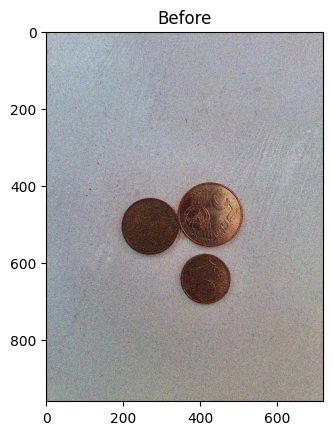

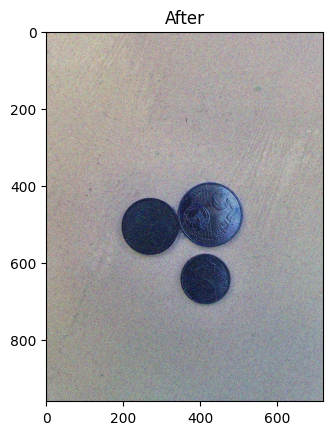

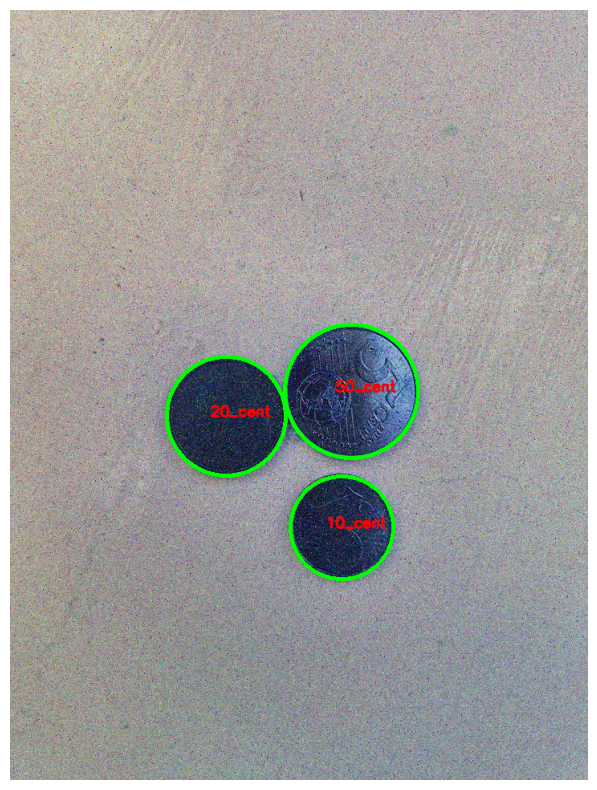

image_1.jpg
Coin 1: 20_cent (0.200 €)
Coin 2: 50_cent (0.500 €)
Coin 3: 10_cent (0.100 €)
Partial Amount: 0.7999999999999999


In [6]:
# VISUAL TEST

sample = sorted(
    Path(TARGET_DIR).glob(
        "*.jpg"
    )
)[0]

coins, amount, vis = process_image(
    sample,
    visualize=True
)

print(sample.name)

for i, c in enumerate(coins):

    print(
        f"Coin {i+1}: "
        f"{c['coin']} "
        f"({c['value']:.3f} €)"
    )

print(
    "Partial Amount:",
    amount
)


In [7]:
# ============================================================
# DATASET EVALUATION
# ============================================================

grand_total = 0


for img_path in image_files:
    coins, amount, _ = process_image(
        img_path
    )

    print(
        f"\n{img_path.name} - "
        f"{len(coins)} coin(s) found:"
    )
    

    # for idx, c in enumerate(coins):

    #     print(
    #         f" Coin {idx+1} "
    #         f"{{value: {c['value']:.3f}}}"
    #     )

    # print(
    #     f" Partial Amount "
    #     f"{{value: {amount:.3f}}}"
    # )

    # grand_total += amount


# print("\n" + "="*50)

# print(
#     f"Total Amount: "
#     f"{grand_total:.2f} €"
# )

NameError: name 'image_files' is not defined

OpenCV: 0.00031375885009765625
1D separable: 0.0021140575408935547
2D: 0.005728006362915039


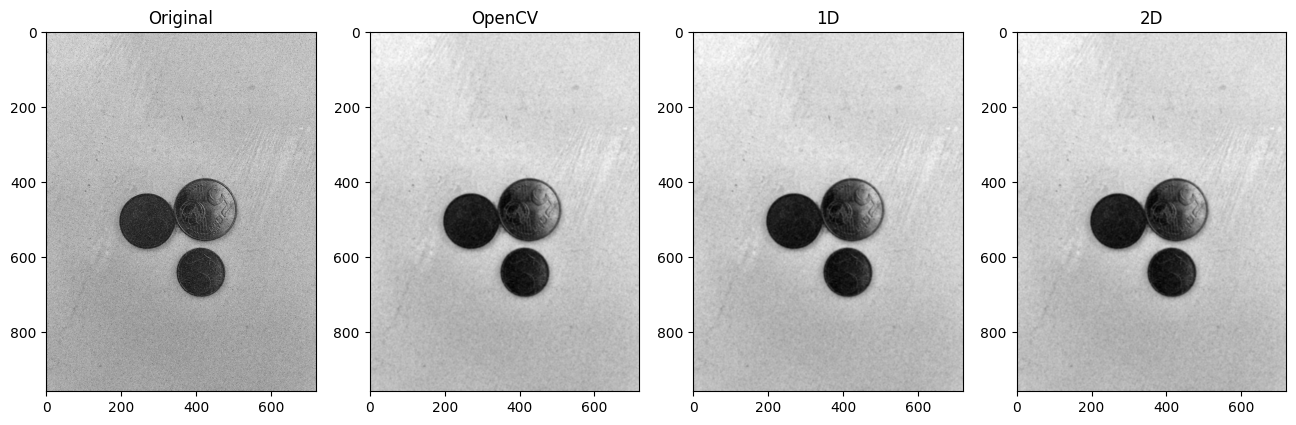

In [ ]:


img = load_image(sample)

gray = cv2.cvtColor(
    img,
    cv2.COLOR_RGB2GRAY
)

# OpenCV Gaussian
t0 = time.time()

g_cv = cv2.GaussianBlur(
    gray,
    (K_SIZE, K_SIZE),
    SIGMA
)

t1 = time.time()

print(
    "OpenCV:",
    t1-t0
)


# Separable 1D kernel
kernel1d = cv2.getGaussianKernel(
    K_SIZE,
    SIGMA
)

t0 = time.time()

temp = cv2.filter2D(
    gray,
    -1,
    kernel1d
)

g1 = cv2.filter2D(
    temp,
    -1,
    kernel1d.T
)

t1 = time.time()

print(
    "1D separable:",
    t1-t0
)


# Full 2D kernel
kernel2d = (
    kernel1d @ kernel1d.T
)

t0 = time.time()

g2 = cv2.filter2D(
    gray,
    -1,
    kernel2d
)

t1 = time.time()

print(
    "2D:",
    t1-t0
)


plt.figure(figsize=(16,5))

plt.subplot(141)
plt.imshow(gray,cmap='gray')
plt.title("Original")

plt.subplot(142)
plt.imshow(g_cv,cmap='gray')
plt.title("OpenCV")

plt.subplot(143)
plt.imshow(g1,cmap='gray')
plt.title("1D")

plt.subplot(144)
plt.imshow(g2,cmap='gray')
plt.title("2D")

plt.show()

## Evaluation criteria
1. **Clarity and conciseness**. Present your work in a readable way: format your code and **comment every important step**;

2. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach **and justify every decision you make**;

3. **Results correctness**. Both instance-level and total monetary value will be evaluated. Note that a thoroughly justified and sound procedure with a lower number of solved instances will be valued **more** than a poorly designed and justified approach that solves more or all instances.

<font color="red"><b>Once again, each step of this assignment must be solved using traditional computer vision techniques.</b></font>